# Random Forest Forecast Review

This notebook evaluates a Random Forest forecaster using the shared monthly demand matrix. The model is selected with the validation period and then evaluated on the untouched test period.

The workflow preserves the chronological forecasting protocol: the model is fitted on the training window, hyperparameters are chosen using validation performance, and test results are reported only after that selection is complete.




## Shared forecasting data

The model uses the saved feature matrix and the fixed chronological train, validation, and test windows. No features are re-derived in this notebook.




In [6]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.forecasting_evaluation import (
    evaluate_supervised_model,
    load_phase5_artifacts,
    save_model_run,
)
from src.models.random_forest import assess_feature_importance_stability, tune_random_forest

artifacts = load_phase5_artifacts(PROJECT_ROOT)
print('Train rows:', len(artifacts['train_y']))
print('Validation rows:', len(artifacts['validation_y']))
print('Test rows:', len(artifacts['test_y']))
print('Feature count:', artifacts['feature_count'])




Train rows: 108
Validation rows: 24
Test rows: 36
Feature count: 28


## Validation-based model selection

A small, explicit configuration set is compared using validation RMSE. The test period is not used to choose the configuration.




In [7]:
model, tuning_results = tune_random_forest(
    artifacts['train_X'],
    artifacts['train_y'],
    artifacts['validation_X'],
    artifacts['validation_y'],
)

display(tuning_results.round(3))
print('Selected configuration:', model.parameters)




,n_estimators,max_depth,min_samples_leaf,mae,rmse,mape,smape,r2
0,300,10.0,1,286119.370,345121.157,7.105,7.345,0.702
1,200,6.0,1,286792.997,346210.111,7.108,7.351,0.700
2,300,NaN,2,291753.289,354905.815,7.223,7.485,0.685


Selected configuration: {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 1}


In [8]:
evaluation = evaluate_supervised_model(
    model,
    artifacts['train_X'],
    artifacts['train_y'],
    artifacts['validation_X'],
    artifacts['validation_y'],
    artifacts['test_X'],
    artifacts['test_y'],
)

metrics = pd.DataFrame(evaluation['metrics']).T
display(metrics.round(3))




,mae,rmse,mape,smape,r2
validation,286119.370,345121.157,7.105,7.345,0.702
test,486348.093,584281.741,11.454,11.838,0.343


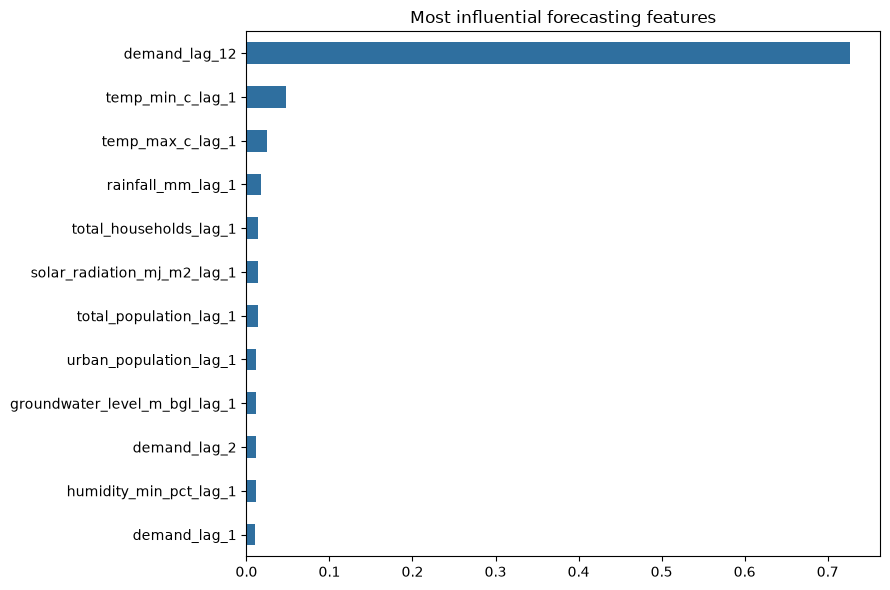

Mean Spearman rank correlation: 0.949
Minimum Spearman rank correlation: 0.909
Mean top-k overlap: 0.872


In [9]:
importance = model.feature_importances_.rename('importance').head(12).sort_values()
importance.plot(kind='barh', figsize=(9, 6), color='#2f6f9f', title='Most influential forecasting features')
plt.tight_layout()
plt.show()

stability = assess_feature_importance_stability(
    artifacts['train_X'],
    artifacts['train_y'],
)
print('Mean Spearman rank correlation:', round(stability['mean_spearman_rank_correlation'], 3))
print('Minimum Spearman rank correlation:', round(stability['minimum_spearman_rank_correlation'], 3))
print('Mean top-k overlap:', round(stability['mean_top_k_overlap'], 3))





{'model': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/models/random_forest_forecaster.joblib'), 'predictions': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/reports/random_forest_forecaster_predictions.csv'), 'metrics': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/metrics/random_forest_forecaster_metrics.json'), 'configuration': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/metrics/random_forest_forecaster_configuration.json'), 'residuals': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/reports/random_forest_forecaster_residuals.csv'), 'residual_diagnostics': WindowsPath('C:/Users/derai/Desktop/ml_based_irrigation/outputs/metrics/random_forest_forecaster_residual_diagnostics.json')}


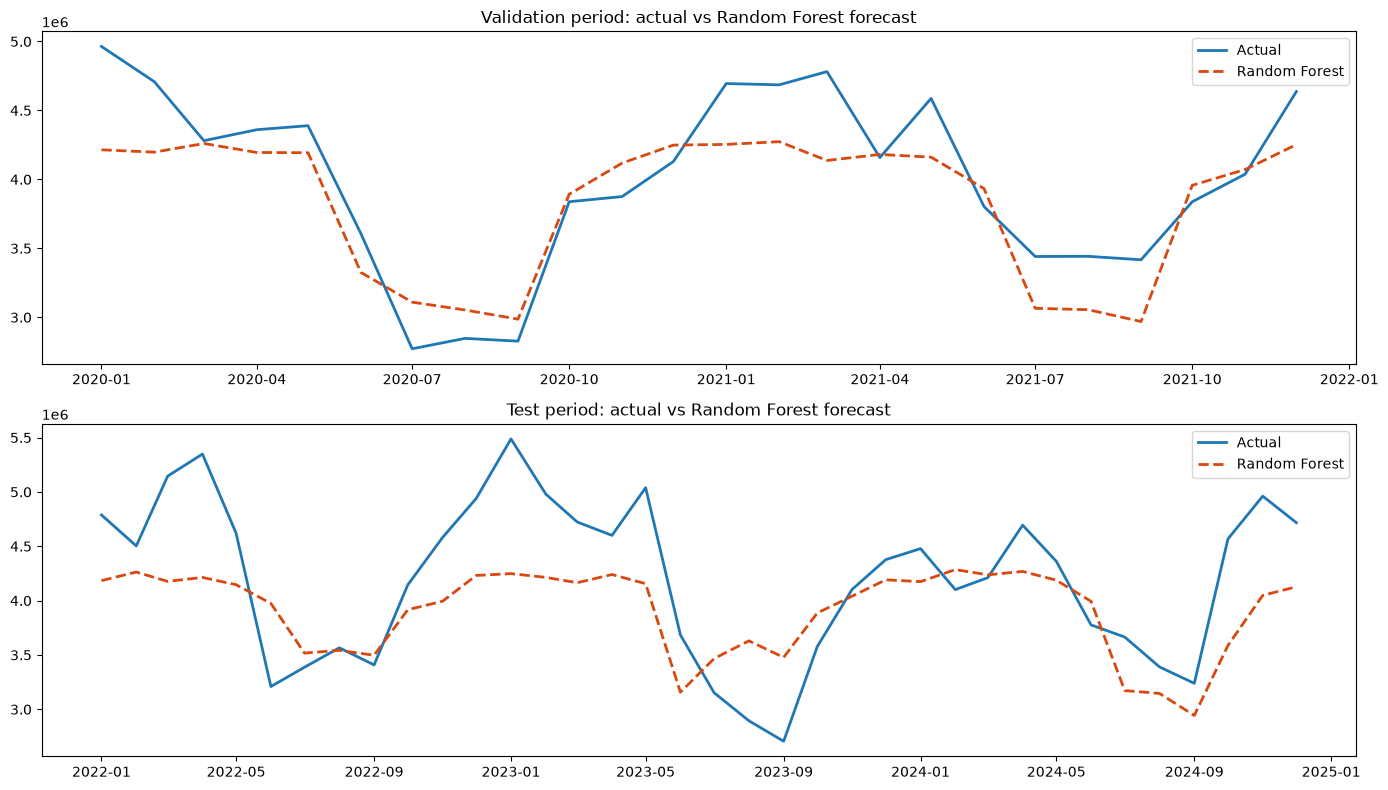

In [10]:
output_dir = PROJECT_ROOT / 'outputs' / 'figures' / 'model_random_forest'
output_dir.mkdir(parents=True, exist_ok=True)

figure, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for axis, split, actual in zip(axes, ('validation', 'test'), (artifacts['validation_y'], artifacts['test_y'])):
    prediction = evaluation['predictions'][split]
    axis.plot(actual.index, actual.values, label='Actual', color='#1f77b4', linewidth=2)
    axis.plot(prediction.index, prediction.values, label='Random Forest', color='#d9480f', linewidth=2, linestyle='--')
    axis.set_title(f'{split.title()} period: actual vs Random Forest forecast')
    axis.legend()
figure.tight_layout()
figure.savefig(output_dir / '01_random_forest_forecasts.png', dpi=180, bbox_inches='tight')

tuning_results.to_csv(PROJECT_ROOT / 'outputs' / 'metrics' / 'random_forest_tuning.csv', index=False)
saved_paths = save_model_run(
    'random_forest_forecaster',
    model,
    evaluation['predictions'],
    evaluation['metrics'],
    {'model': 'RandomForestRegressor', 'selected_parameters': model.parameters, 'feature_columns': artifacts['feature_columns']},
    PROJECT_ROOT,
    targets={'validation': artifacts['validation_y'], 'test': artifacts['test_y']},
)
stability['importance'].to_csv(PROJECT_ROOT / 'outputs' / 'metrics' / 'random_forest_feature_importance.csv')
stability['rank_correlation'].to_csv(PROJECT_ROOT / 'outputs' / 'metrics' / 'random_forest_feature_rank_correlation.csv')
(PROJECT_ROOT / 'outputs' / 'metrics' / 'random_forest_feature_stability.json').write_text(json.dumps({
    'mean_spearman_rank_correlation': stability['mean_spearman_rank_correlation'],
    'minimum_spearman_rank_correlation': stability['minimum_spearman_rank_correlation'],
    'mean_top_k_overlap': stability['mean_top_k_overlap'],
    'top_k': stability['top_k'],
}, indent=2))
print(saved_paths)




## Interpretation

The validation score supports configuration selection, while the test score provides the held-out estimate of forecasting performance. Feature importance is descriptive rather than causal: it identifies which shared predictors the fitted forest used most strongly for this synthetic forecasting dataset.


